# Taller: Procesamiento de texto
## Curso: Procesamiento de Lenguaje Natural (PLN)

**Duración:** 2 horas · **Herramienta:** Google Colab · **Idioma de los textos:** español

---

### ¿Qué vamos a hacer?

En este taller vamos a recorrer, **paso a paso**, el camino completo que sigue un texto cuando lo procesa un computador:

1. Primero lo **limpiamos y lo partimos** en piezas (normalización, tokens, stopwords, stemming, lematización).
2. Después lo **analizamos gramaticalmente** (etiquetas POS, parsing, entidades nombradas).
3. Luego lo **convertimos en números** para que un algoritmo pueda trabajar con él (TF, IDF, TF-IDF, minería de texto).
4. Finalmente usamos **modelos de lenguaje preentrenados** (Hugging Face) para tareas avanzadas: similitud, clasificación, preguntas y respuestas, resumen, traducción y generación de texto con un LLM.

### ¿Cómo usar este notebook?

* Ejecuta las celdas **en orden**, de arriba hacia abajo, con el botón de reproducir o con `Shift + Enter`.
* Cada sección tiene: una **explicación** (¿qué es y para qué sirve?), el **código** comentado línea por línea, y un **ejercicio** corto para que lo pruebes con tus propios textos.
* No necesitas experiencia previa en programación: el código está explicado en cada línea.
* Las secciones 12 a 18 descargan modelos de Hugging Face (entre 100 MB y 1 GB cada uno). La primera vez tardan un poco; es normal.

> **Recomendación:** antes de empezar ve a `Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU`. No es obligatorio, pero las secciones finales serán mucho más rápidas.

### Agenda sugerida (2 horas)

| Tiempo | Bloque | Secciones |
|---|---|---|
| 0:00 – 0:10 | Instalación y corpus de trabajo | 0 – 1 |
| 0:10 – 0:40 | Preprocesamiento clásico | 2 – 6 |
| 0:40 – 1:00 | Análisis lingüístico con spaCy | 7 – 9 |
| 1:00 – 1:20 | Representación numérica y minería de texto | 10 – 11 |
| 1:20 – 1:55 | Tareas con modelos preentrenados y LLM | 12 – 18 |
| 1:55 – 2:00 | Cierre y entrega | 19 |

## 0. Instalación de librerías

Colab ya trae muchas librerías instaladas, pero necesitamos algunas adicionales. Ejecuta la celda siguiente **una sola vez** (tarda 1 a 2 minutos).

Librerías que usaremos:

| Librería | ¿Para qué? |
|---|---|
| `nltk` | Caja de herramientas clásica de PLN: tokenización, stopwords, stemming |
| `spacy` | Análisis lingüístico moderno: lematización, POS, parsing, entidades |
| `scikit-learn` | TF, TF-IDF, clasificación clásica, agrupamiento |
| `transformers` | Modelos preentrenados de Hugging Face (BERT, T5, GPT, LLMs) |
| `sentence-transformers` | Vectores (embeddings) de oraciones para medir similitud |
| `wordcloud` | Nubes de palabras para minería de texto |

In [1]:
# El signo "!" al inicio le dice a Colab que ejecute un comando del sistema (no de Python).
# "-q" significa "quiet": muestra menos mensajes.
!pip install -q nltk spacy scikit-learn transformers sentence-transformers wordcloud sentencepiece sacremoses accelerate

# Descargamos el modelo de spaCy para ESPAÑOL (tamaño "sm" = small, pequeño y rápido)
!python -m spacy download es_core_news_sm -q

print("Instalación terminada")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 30.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Instalación terminada


In [2]:
# Importamos las librerías que usaremos en todo el taller
import re                      # expresiones regulares: buscar y reemplazar patrones en texto
import unicodedata             # manejo de acentos y caracteres especiales
import pandas as pd            # tablas de datos (DataFrames)
import numpy as np             # cálculo numérico
import matplotlib.pyplot as plt  # gráficos

import nltk                    # Natural Language Toolkit
# Recursos de NLTK que se descargan aparte de la librería:
nltk.download("punkt_tab", quiet=True)   # tokenizador de oraciones y palabras
nltk.download("stopwords", quiet=True)   # listas de palabras vacías en varios idiomas

import spacy
nlp = spacy.load("es_core_news_sm")      # cargamos el modelo de español en la variable "nlp"

print("Librerías cargadas. spaCy versión:", spacy.__version__)

Librerías cargadas. spaCy versión: 3.8.16


## 1. Corpus de trabajo

En PLN, un **corpus** es simplemente una colección de textos. Para el taller usaremos un corpus pequeño de **8 noticias breves en español** (escritas para este ejercicio) sobre cuatro temas: *tecnología, deporte, economía y salud*.

Tener un corpus pequeño y conocido nos permite **ver con nuestros ojos** lo que hace cada técnica. Al final del taller podrás reemplazarlo por tus propios textos.

In [3]:
# Cada documento es un diccionario con un identificador, un tema (etiqueta) y el texto.
corpus = [
    {"id": 1, "tema": "tecnologia",
     "texto": "La Universidad Nacional de Colombia presentó en Bogotá un nuevo laboratorio de inteligencia artificial. "
              "Los investigadores entrenarán modelos de lenguaje en español para analizar documentos públicos. "
              "El proyecto cuenta con el apoyo del Ministerio de Ciencia y de la empresa Google."},
    {"id": 2, "tema": "tecnologia",
     "texto": "Una startup de Medellín desarrolló una aplicación que detecta correos fraudulentos usando aprendizaje automático. "
              "La herramienta analiza el texto del mensaje y avisa al usuario cuando encuentra señales de phishing. "
              "Ya la utilizan más de 20.000 personas en Colombia y México."},
    {"id": 3, "tema": "deporte",
     "texto": "La Selección Colombia venció 2-1 a Argentina en el estadio Metropolitano de Barranquilla. "
              "Los goles fueron anotados por Luis Díaz en la segunda mitad del partido. "
              "El equipo dirigido por Néstor Lorenzo sigue invicto en las eliminatorias."},
    {"id": 4, "tema": "deporte",
     "texto": "El ciclista Egan Bernal ganó la etapa de montaña de la Vuelta a Colombia tras un ataque en el último kilómetro. "
              "El corredor de Zipaquirá recuperó su mejor nivel después de dos años de lesiones. "
              "Miles de aficionados lo esperaban en la meta."},
    {"id": 5, "tema": "economia",
     "texto": "El Banco de la República decidió reducir la tasa de interés en 25 puntos básicos. "
              "La decisión busca estimular el consumo y la inversión en un contexto de inflación a la baja. "
              "Los analistas esperan nuevas reducciones antes de finalizar el año."},
    {"id": 6, "tema": "economia",
     "texto": "El precio del café colombiano alcanzó su nivel más alto en una década en la bolsa de Nueva York. "
              "Los caficultores de Antioquia y Huila celebran el aumento, aunque temen que la sequía afecte la próxima cosecha. "
              "Las exportaciones crecieron un 15 por ciento."},
    {"id": 7, "tema": "salud",
     "texto": "El Ministerio de Salud lanzó una campaña nacional de vacunación contra la influenza. "
              "Las vacunas estarán disponibles gratis en hospitales y centros de salud de todo el país. "
              "Los médicos recomiendan vacunarse antes de la temporada de lluvias."},
    {"id": 8, "tema": "salud",
     "texto": "Un estudio de la Universidad de Antioquia encontró que caminar 30 minutos diarios reduce el riesgo de enfermedades cardíacas. "
              "Los investigadores siguieron a 5.000 pacientes durante cinco años. "
              "Los resultados fueron publicados en una revista médica internacional."},
]

# Convertimos la lista en una tabla (DataFrame) para verla mejor
df = pd.DataFrame(corpus)
pd.set_option("display.max_colwidth", 120)   # mostrar más texto por celda
df

,id,tema,texto
0,1,tecnologia,La Universidad Nacional de Colombia presentó en Bogotá un nuevo laboratorio de inteligencia artificial. Los investig...
1,2,tecnologia,Una startup de Medellín desarrolló una aplicación que detecta correos fraudulentos usando aprendizaje automático. La...
2,3,deporte,La Selección Colombia venció 2-1 a Argentina en el estadio Metropolitano de Barranquilla. Los goles fueron anotados ...
3,4,deporte,El ciclista Egan Bernal ganó la etapa de montaña de la Vuelta a Colombia tras un ataque en el último kilómetro. El c...
4,5,economia,El Banco de la República decidió reducir la tasa de interés en 25 puntos básicos. La decisión busca estimular el con...
5,6,economia,El precio del café colombiano alcanzó su nivel más alto en una década en la bolsa de Nueva York. Los caficultores de...
6,7,salud,El Ministerio de Salud lanzó una campaña nacional de vacunación contra la influenza. Las vacunas estarán disponibles...
7,8,salud,Un estudio de la Universidad de Antioquia encontró que caminar 30 minutos diarios reduce el riesgo de enfermedades c...


In [4]:
# Guardamos también un texto de ejemplo individual que reutilizaremos en varias secciones
texto_ejemplo = corpus[0]["texto"]
print(texto_ejemplo)

La Universidad Nacional de Colombia presentó en Bogotá un nuevo laboratorio de inteligencia artificial. Los investigadores entrenarán modelos de lenguaje en español para analizar documentos públicos. El proyecto cuenta con el apoyo del Ministerio de Ciencia y de la empresa Google.


## 2. Normalización de texto

### ¿Qué es?
**Normalizar** es llevar el texto a una forma estándar y uniforme para que el computador no trate como distintas cosas que para nosotros son iguales. Por ejemplo, para una persona `Bogotá`, `bogotá` y `BOGOTÁ` son la misma palabra, pero para el computador son tres cadenas diferentes.

### Pasos típicos
1. Pasar todo a **minúsculas**.
2. Quitar **signos de puntuación** y **números** (según el caso).
3. Eliminar **espacios repetidos**.
4. (Opcional) quitar **acentos**. En español esto es delicado: `más` ≠ `mas`, así que lo mostraremos pero lo dejaremos como decisión del analista.

### ¿Para qué sirve?
Es el primer paso de casi cualquier proyecto de PLN: reduce el "ruido" y el tamaño del vocabulario.

In [5]:
def normalizar(texto, quitar_acentos=False):
    # 1. Minúsculas
    texto = texto.lower()

    # 2. (Opcional) quitar acentos: descomponemos cada letra acentuada en letra + tilde
    #    y eliminamos la tilde (categoría "Mn" = marca no espaciadora)
    if quitar_acentos:
        texto = "".join(c for c in unicodedata.normalize("NFD", texto)
                        if unicodedata.category(c) != "Mn")

    # 3. Quitar números
    texto = re.sub(r"\d+", " ", texto)

    # 4. Quitar todo lo que NO sea letra (incluye ñ y vocales con tilde) o espacio
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)

    # 5. Colapsar espacios múltiples y quitar espacios al inicio y al final
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

print("ORIGINAL:\n", texto_ejemplo)
print("\nNORMALIZADO (conservando acentos):\n", normalizar(texto_ejemplo))
print("\nNORMALIZADO (sin acentos):\n", normalizar(texto_ejemplo, quitar_acentos=True))

ORIGINAL:
 La Universidad Nacional de Colombia presentó en Bogotá un nuevo laboratorio de inteligencia artificial. Los investigadores entrenarán modelos de lenguaje en español para analizar documentos públicos. El proyecto cuenta con el apoyo del Ministerio de Ciencia y de la empresa Google.

NORMALIZADO (conservando acentos):
 la universidad nacional de colombia presentó en bogotá un nuevo laboratorio de inteligencia artificial los investigadores entrenarán modelos de lenguaje en español para analizar documentos públicos el proyecto cuenta con el apoyo del ministerio de ciencia y de la empresa google

NORMALIZADO (sin acentos):
 la universidad nacional de colombia presento en bogota un nuevo laboratorio de inteligencia artificial los investigadores entrenaran modelos de lenguaje en espanol para analizar documentos publicos el proyecto cuenta con el apoyo del ministerio de ciencia y de la empresa google


### Tokenización: partir el texto en palabras

Después de normalizar, dividimos el texto en unidades llamadas **tokens** (normalmente palabras). Parece trivial —"separar por espacios"— pero los tokenizadores manejan casos como `20.000`, `2-1` o `Dr.` mejor que un simple `split()`.

In [6]:
from nltk.tokenize import word_tokenize, sent_tokenize

# Tokenización en ORACIONES (útil para resúmenes, QA, etc.)
oraciones = sent_tokenize(texto_ejemplo, language="spanish")
print("Número de oraciones:", len(oraciones))
for i, o in enumerate(oraciones, 1):
    print(f"  {i}. {o}")

# Tokenización en PALABRAS sobre el texto normalizado
tokens = word_tokenize(normalizar(texto_ejemplo), language="spanish")
print("\nNúmero de tokens:", len(tokens))
print(tokens)

Número de oraciones: 3
  1. La Universidad Nacional de Colombia presentó en Bogotá un nuevo laboratorio de inteligencia artificial.
  2. Los investigadores entrenarán modelos de lenguaje en español para analizar documentos públicos.
  3. El proyecto cuenta con el apoyo del Ministerio de Ciencia y de la empresa Google.

Número de tokens: 41
['la', 'universidad', 'nacional', 'de', 'colombia', 'presentó', 'en', 'bogotá', 'un', 'nuevo', 'laboratorio', 'de', 'inteligencia', 'artificial', 'los', 'investigadores', 'entrenarán', 'modelos', 'de', 'lenguaje', 'en', 'español', 'para', 'analizar', 'documentos', 'públicos', 'el', 'proyecto', 'cuenta', 'con', 'el', 'apoyo', 'del', 'ministerio', 'de', 'ciencia', 'y', 'de', 'la', 'empresa', 'google']


In [7]:
# Aplicamos normalización + tokenización a TODO el corpus y guardamos el resultado en la tabla
df["texto_norm"] = df["texto"].apply(normalizar)
df["tokens"] = df["texto_norm"].apply(lambda t: word_tokenize(t, language="spanish"))
df[["id", "tema", "tokens"]]

,id,tema,tokens
0,1,tecnologia,"[la, universidad, nacional, de, colombia, presentó, en, bogotá, un, nuevo, laboratorio, de, inteligencia, artificial..."
1,2,tecnologia,"[una, startup, de, medellín, desarrolló, una, aplicación, que, detecta, correos, fraudulentos, usando, aprendizaje, ..."
2,3,deporte,"[la, selección, colombia, venció, a, argentina, en, el, estadio, metropolitano, de, barranquilla, los, goles, fueron..."
3,4,deporte,"[el, ciclista, egan, bernal, ganó, la, etapa, de, montaña, de, la, vuelta, a, colombia, tras, un, ataque, en, el, úl..."
4,5,economia,"[el, banco, de, la, república, decidió, reducir, la, tasa, de, interés, en, puntos, básicos, la, decisión, busca, es..."
5,6,economia,"[el, precio, del, café, colombiano, alcanzó, su, nivel, más, alto, en, una, década, en, la, bolsa, de, nueva, york, ..."
6,7,salud,"[el, ministerio, de, salud, lanzó, una, campaña, nacional, de, vacunación, contra, la, influenza, las, vacunas, esta..."
7,8,salud,"[un, estudio, de, la, universidad, de, antioquia, encontró, que, caminar, minutos, diarios, reduce, el, riesgo, de, ..."


> **Ejercicio 2:** escribe un texto propio (un mensaje de WhatsApp, un tuit, un párrafo de un artículo) en la variable `mi_texto` y observa cómo cambia con `normalizar`. ¿Qué información se pierde al quitar los números? ¿Cuándo sería un problema?

In [8]:
mi_texto = "Escribe aquí tu propio texto... ¡con MAYÚSCULAS, números como 2024 y signos!"
print(normalizar(mi_texto))
print(word_tokenize(normalizar(mi_texto), language="spanish"))

escribe aquí tu propio texto con mayúsculas números como y signos
['escribe', 'aquí', 'tu', 'propio', 'texto', 'con', 'mayúsculas', 'números', 'como', 'y', 'signos']


## 3. Stopwords (palabras vacías)

### ¿Qué es?
Las **stopwords** son palabras muy frecuentes que aportan poco significado por sí solas: artículos (*el, la, los*), preposiciones (*de, en, con*), pronombres (*yo, su*), conjunciones (*y, que*)...

### ¿Para qué sirve eliminarlas?
Si contamos palabras en cualquier texto en español, "de", "la" y "el" siempre ganan. Al quitarlas, las palabras **realmente informativas** (café, vacuna, gol) salen a la superficie. También reduce el tamaño de los datos.

> **Nota:** No siempre conviene eliminarlas. Para análisis de sentimiento, la palabra *no* es una stopword pero cambia todo el significado ("no me gustó").

In [9]:
from nltk.corpus import stopwords

stop_es = set(stopwords.words("spanish"))   # usamos un "set" porque buscar en él es muy rápido
print("NLTK tiene", len(stop_es), "stopwords en español. Algunas:")
print(sorted(list(stop_es))[:40])

NLTK tiene 313 stopwords en español. Algunas:
['a', 'al', 'algo', 'algunas', 'algunos', 'ante', 'antes', 'como', 'con', 'contra', 'cual', 'cuando', 'de', 'del', 'desde', 'donde', 'durante', 'e', 'el', 'ella', 'ellas', 'ellos', 'en', 'entre', 'era', 'erais', 'eran', 'eras', 'eres', 'es', 'esa', 'esas', 'ese', 'eso', 'esos', 'esta', 'estaba', 'estabais', 'estaban', 'estabas']


In [10]:
def quitar_stopwords(tokens):
    # Nos quedamos solo con los tokens que NO están en la lista de stopwords
    return [t for t in tokens if t not in stop_es]

print("ANTES :", tokens)
print("\nDESPUÉS:", quitar_stopwords(tokens))
print(f"\nPasamos de {len(tokens)} a {len(quitar_stopwords(tokens))} tokens")

ANTES : ['la', 'universidad', 'nacional', 'de', 'colombia', 'presentó', 'en', 'bogotá', 'un', 'nuevo', 'laboratorio', 'de', 'inteligencia', 'artificial', 'los', 'investigadores', 'entrenarán', 'modelos', 'de', 'lenguaje', 'en', 'español', 'para', 'analizar', 'documentos', 'públicos', 'el', 'proyecto', 'cuenta', 'con', 'el', 'apoyo', 'del', 'ministerio', 'de', 'ciencia', 'y', 'de', 'la', 'empresa', 'google']

DESPUÉS: ['universidad', 'nacional', 'colombia', 'presentó', 'bogotá', 'nuevo', 'laboratorio', 'inteligencia', 'artificial', 'investigadores', 'entrenarán', 'modelos', 'lenguaje', 'español', 'analizar', 'documentos', 'públicos', 'proyecto', 'cuenta', 'apoyo', 'ministerio', 'ciencia', 'empresa', 'google']

Pasamos de 41 a 24 tokens


In [11]:
# Aplicamos al corpus completo
df["tokens_sin_stop"] = df["tokens"].apply(quitar_stopwords)

# ¿Cuáles son las palabras más frecuentes del corpus ANTES y DESPUÉS de quitar stopwords?
from collections import Counter

todas = Counter(t for lista in df["tokens"] for t in lista)
todas_sin_stop = Counter(t for lista in df["tokens_sin_stop"] for t in lista)

print("Top 10 CON stopwords :", todas.most_common(10))
print("Top 10 SIN stopwords :", todas_sin_stop.most_common(10))

Top 10 CON stopwords : [('de', 30), ('la', 20), ('el', 16), ('en', 14), ('los', 7), ('y', 6), ('un', 5), ('una', 5), ('colombia', 4), ('del', 4)]
Top 10 SIN stopwords : [('colombia', 4), ('universidad', 2), ('nacional', 2), ('investigadores', 2), ('ministerio', 2), ('nivel', 2), ('años', 2), ('antioquia', 2), ('salud', 2), ('presentó', 1)]


> **Ejercicio 3:** agrega a `stop_es` palabras que en *este* corpus no aportan información (por ejemplo `"según"`, `"tras"`) usando `stop_es.add("palabra")` y vuelve a ejecutar la celda anterior. ¿Cambia el top 10?

## 4. Stemming (raíces)

### ¿Qué es?
El **stemming** recorta las palabras para dejar solo su "raíz" aproximada, eliminando terminaciones. Así, *investigador*, *investigadores*, *investigación* e *investigar* se reducen a algo como `investig`.

### ¿Cómo funciona?
Con **reglas** de corte (por ejemplo: "si termina en *-ción*, quítalo"). Es rápido pero **tosco**: la raíz resultante muchas veces **no es una palabra real**.

### ¿Para qué sirve?
Para agrupar variantes de una misma palabra en buscadores y conteos, cuando no importa que el resultado sea legible. Usaremos el algoritmo **Snowball**, que tiene versión para español.

In [12]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("spanish")

palabras = ["investigador", "investigadores", "investigación", "investigar",
            "vacuna", "vacunas", "vacunación", "vacunarse",
            "corriendo", "corredor", "corrió", "niños", "niña"]

for p in palabras:
    print(f"{p:15} → {stemmer.stem(p)}")

investigador    → investig
investigadores  → investig
investigación   → investig
investigar      → investig
vacuna          → vacun
vacunas         → vacun
vacunación      → vacun
vacunarse       → vacun
corriendo       → corr
corredor        → corredor
corrió          → corr
niños           → niñ
niña            → niñ


In [13]:
# Stemming del corpus (sobre los tokens sin stopwords)
df["stems"] = df["tokens_sin_stop"].apply(lambda ts: [stemmer.stem(t) for t in ts])

print("Tokens :", df.loc[0, "tokens_sin_stop"])
print("\nStems  :", df.loc[0, "stems"])

Tokens : ['universidad', 'nacional', 'colombia', 'presentó', 'bogotá', 'nuevo', 'laboratorio', 'inteligencia', 'artificial', 'investigadores', 'entrenarán', 'modelos', 'lenguaje', 'español', 'analizar', 'documentos', 'públicos', 'proyecto', 'cuenta', 'apoyo', 'ministerio', 'ciencia', 'empresa', 'google']

Stems  : ['univers', 'nacional', 'colombi', 'present', 'bogot', 'nuev', 'laboratori', 'inteligent', 'artificial', 'investig', 'entren', 'model', 'lenguaj', 'español', 'analiz', 'document', 'public', 'proyect', 'cuent', 'apoy', 'ministeri', 'cienci', 'empres', 'googl']


Observa que `inteligencia` → `inteligent`, `laboratorio` → `laboratori`. Son raíces útiles para agrupar, pero no palabras del diccionario. En la sección 6 veremos la **lematización**, que resuelve ese problema.

## 5. Term Frequency (TF): frecuencia de términos

### ¿Qué es?
**TF** (frecuencia de término) mide cuántas veces aparece cada palabra en un documento. Es la forma más simple de convertir texto en números: cada documento se vuelve un **vector** donde cada posición es una palabra del vocabulario y el valor es su conteo.

A esta representación se le llama **bolsa de palabras** (*bag of words*): guardamos qué palabras hay y cuántas veces, pero **perdemos el orden**.

### Fórmula
La versión más usada normaliza por la longitud del documento, para que un documento largo no "gane" solo por tener más palabras:

$$TF(t, d) = \frac{\text{número de veces que } t \text{ aparece en } d}{\text{número total de términos en } d}$$

In [14]:
# Primero lo calculamos "a mano" para entenderlo
doc = df.loc[0, "tokens_sin_stop"]          # tokens del documento 1
conteo = Counter(doc)                        # cuenta cada palabra
total = len(doc)

tf_manual = {palabra: n / total for palabra, n in conteo.items()}

# Mostramos ordenado de mayor a menor
for palabra, valor in sorted(tf_manual.items(), key=lambda x: -x[1])[:8]:
    print(f"{palabra:15} conteo={conteo[palabra]}  TF={valor:.3f}")

universidad     conteo=1  TF=0.042
nacional        conteo=1  TF=0.042
colombia        conteo=1  TF=0.042
presentó        conteo=1  TF=0.042
bogotá          conteo=1  TF=0.042
nuevo           conteo=1  TF=0.042
laboratorio     conteo=1  TF=0.042
inteligencia    conteo=1  TF=0.042


In [15]:
# Ahora con scikit-learn, que lo hace para todo el corpus de una vez
from sklearn.feature_extraction.text import CountVectorizer

# Le pasamos los textos ya limpios (unidos de nuevo como texto) y nuestras stopwords
textos_limpios = df["tokens_sin_stop"].apply(" ".join)

vectorizador = CountVectorizer()
X_tf = vectorizador.fit_transform(textos_limpios)   # matriz documentos × palabras

print("Forma de la matriz (documentos, vocabulario):", X_tf.shape)

# Convertimos a tabla para verla: filas = documentos, columnas = palabras
tabla_tf = pd.DataFrame(X_tf.toarray(),
                        columns=vectorizador.get_feature_names_out(),
                        index=[f"doc{i}" for i in df["id"]])

# Mostramos solo algunas columnas interesantes
tabla_tf[["colombia", "café", "vacunas", "goles", "inteligencia", "investigadores", "salud"]]

Forma de la matriz (documentos, vocabulario): (8, 168)


,colombia,café,vacunas,goles,inteligencia,investigadores,salud
doc1,1,0,0,0,1,1,0
doc2,1,0,0,0,0,0,0
doc3,1,0,0,1,0,0,0
doc4,1,0,0,0,0,0,0
doc5,0,0,0,0,0,0,0
doc6,0,1,0,0,0,0,0
doc7,0,0,1,0,0,0,2
doc8,0,0,0,0,0,1,0


Cada fila es un documento convertido en números. Fíjate en que `colombia` aparece en varios documentos de temas distintos: es frecuente pero **poco discriminativa**. Ese es justo el problema que resuelve la siguiente sección.

## 6. Inverse Document Frequency (IDF) y TF-IDF

### ¿Qué es?
**IDF** (frecuencia inversa de documento) mide qué tan *rara* es una palabra en el corpus completo. Una palabra que aparece en **todos** los documentos (como *colombia* aquí) tiene IDF bajo; una que aparece en **uno solo** (como *café*) tiene IDF alto.

$$IDF(t) = \log\frac{N}{n_t}$$

donde $N$ es el número total de documentos y $n_t$ el número de documentos que contienen el término $t$.

### TF-IDF
Al multiplicar ambas medidas obtenemos **TF-IDF**: un peso alto para palabras que son **frecuentes en este documento** pero **raras en el resto**. Es decir, las palabras que mejor describen de qué trata *este* documento.

$$TFIDF(t, d) = TF(t, d) \times IDF(t)$$

### ¿Para qué sirve?
Es la base de los buscadores clásicos, de la extracción de palabras clave y de muchos clasificadores de texto.

In [16]:
# IDF a mano para algunas palabras
N = len(df)

def idf_manual(palabra):
    n_t = sum(1 for tokens in df["tokens_sin_stop"] if palabra in tokens)  # ¿en cuántos docs aparece?
    return np.log(N / n_t) if n_t > 0 else 0, n_t

for p in ["colombia", "investigadores", "café", "goles", "salud"]:
    valor, n_t = idf_manual(p)
    print(f"{p:15} aparece en {n_t} de {N} docs → IDF = {valor:.3f}")

colombia        aparece en 4 de 8 docs → IDF = 0.693
investigadores  aparece en 2 de 8 docs → IDF = 1.386
café            aparece en 1 de 8 docs → IDF = 2.079
goles           aparece en 1 de 8 docs → IDF = 2.079
salud           aparece en 1 de 8 docs → IDF = 2.079


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# scikit-learn usa una versión "suavizada" de la fórmula (suma 1 para evitar divisiones por cero),
# por eso los números serán algo distintos a los manuales, pero el orden se conserva.
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(textos_limpios)

tabla_tfidf = pd.DataFrame(X_tfidf.toarray(),
                           columns=tfidf.get_feature_names_out(),
                           index=[f"doc{i}" for i in df["id"]])

# Las 5 palabras con mayor TF-IDF de cada documento = sus "palabras clave"
for i, fila in tabla_tfidf.iterrows():
    top = fila.sort_values(ascending=False).head(5)
    print(f"{i} ({df.loc[int(i[3:]) - 1, 'tema']:10}):", ", ".join(f"{p} ({v:.2f})" for p, v in top.items()))

doc1 (tecnologia): analizar (0.21), ciencia (0.21), artificial (0.21), apoyo (0.21), bogotá (0.21)
doc2 (tecnologia): analiza (0.21), avisa (0.21), aprendizaje (0.21), aplicación (0.21), automático (0.21)
doc3 (deporte   ): anotados (0.22), argentina (0.22), barranquilla (0.22), invicto (0.22), eliminatorias (0.22)
doc4 (deporte   ): aficionados (0.20), ciclista (0.20), bernal (0.20), ataque (0.20), dos (0.20)
doc5 (economia  ): analistas (0.21), año (0.21), banco (0.21), básicos (0.21), busca (0.21)
doc6 (economia  ): afecte (0.21), alcanzó (0.21), alto (0.21), celebran (0.21), ciento (0.21)
doc7 (salud     ): salud (0.44), centros (0.22), hospitales (0.22), campaña (0.22), gratis (0.22)
doc8 (salud     ): cinco (0.22), caminar (0.22), cardíacas (0.22), internacional (0.22), estudio (0.22)


> **Ejercicio 6:** compara el resultado anterior con `tabla_tf`. ¿Por qué *colombia* ya no aparece entre las palabras clave? Prueba a agregar un noveno documento al corpus que hable de café y observa cómo baja el TF-IDF de esa palabra en el documento 6.

## 7. Lematización

### ¿Qué es?
La **lematización** también reduce las palabras a una forma base, pero a diferencia del stemming usa un **diccionario y análisis gramatical** para devolver el **lema**: la palabra tal como aparece en el diccionario.

| Palabra | Stem (Snowball) | Lema (spaCy) |
|---|---|---|
| investigadores | investig | investigador |
| corrió | corr | correr |
| niños | niñ | niño |

### ¿Para qué sirve?
Cuando necesitamos agrupar variantes **y** que el resultado siga siendo legible (nubes de palabras, informes, búsquedas). Es más lento que el stemming porque necesita entender la oración.

Desde aquí usaremos **spaCy**, que procesa un texto y devuelve un objeto `Doc` lleno de información sobre cada token.

In [18]:
doc_spacy = nlp(texto_ejemplo)   # spaCy analiza el texto completo (tokeniza, etiqueta, lematiza, todo a la vez)

print(f"{'TOKEN':18} {'LEMA':18} {'STEM':15}")
print("-" * 52)
for token in doc_spacy[:20]:            # mostramos los primeros 20 tokens
    if not token.is_punct:              # saltamos la puntuación
        print(f"{token.text:18} {token.lemma_:18} {stemmer.stem(token.text.lower()):15}")

TOKEN              LEMA               STEM           
----------------------------------------------------
La                 el                 la             
Universidad        Universidad        univers        
Nacional           Nacional           nacional       
de                 de                 de             
Colombia           Colombia           colombi        
presentó           presentar          present        
en                 en                 en             
Bogotá             Bogotá             bogot          
un                 uno                un             
nuevo              nuevo              nuev           
laboratorio        laboratorio        laboratori     
de                 de                 de             
inteligencia       inteligencia       inteligent     
artificial         artificial         artificial     
Los                el                 los            
investigadores     investigador       investig       
entrenarán         entrenar  

In [19]:
def lematizar(texto):
    doc = nlp(texto)
    # Nos quedamos con el lema (en minúscula) de los tokens que son palabras
    # y que no son stopwords según spaCy
    return [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]

df["lemas"] = df["texto"].apply(lematizar)
df[["id", "lemas"]]

,id,lemas
0,1,"[universidad, nacional, colombia, presentar, bogotá, laboratorio, inteligencia, artificial, investigador, entrenar, ..."
1,2,"[startup, medellín, desarrollar, aplicación, detectar, correo, fraudulento, usar, aprendizaje, automático, herramien..."
2,3,"[selección, colombia, vencer, argentina, estadio, metropolitano, barranquilla, gol, anotar, luis, díaz, mitad, parti..."
3,4,"[ciclista, egan, bernal, ganar, etapa, montaña, vuelta, colombia, ataque, kilómetro, corredor, zipaquirá, recuperar,..."
4,5,"[banco, república, decidir, reducir, tasa, interés, punto, básico, decisión, buscar, estimular, consumo, inversión, ..."
5,6,"[precio, café, colombiano, alcanzar, nivel, alto, década, bolsa, york, caficultor, antioquia, huila, celebrar, aumen..."
6,7,"[ministerio, salud, lanzar, campaña, nacional, vacunación, influenza, vacuna, estar, disponible, gratis, hospital, c..."
7,8,"[estudio, universidad, antioquia, encontrar, caminar, minuto, diario, reducir, riesgo, enfermedad, cardíaca, investi..."


## 8. Part-of-Speech Tagging (etiquetado gramatical)

### ¿Qué es?
El **POS tagging** asigna a cada palabra su **categoría gramatical**: sustantivo, verbo, adjetivo, preposición, nombre propio... spaCy usa las etiquetas del estándar *Universal Dependencies*:

| Etiqueta | Significado | Ejemplo |
|---|---|---|
| `NOUN` | sustantivo | laboratorio |
| `PROPN` | nombre propio | Bogotá |
| `VERB` | verbo | presentó |
| `ADJ` | adjetivo | nuevo |
| `ADP` | preposición | de, en |
| `DET` | determinante | el, un |
| `PRON` | pronombre | ellos |
| `ADV` | adverbio | muy |
| `NUM` | número | 20.000 |

### ¿Para qué sirve?
Para extraer solo los sustantivos (temas), solo los verbos (acciones) o los adjetivos (opiniones), y como paso previo a la lematización, el parsing y la extracción de entidades.

In [20]:
print(f"{'TOKEN':18} {'POS':8} {'EXPLICACIÓN':22} {'DETALLE MORFOLÓGICO'}")
print("-" * 90)
for token in doc_spacy[:22]:
    print(f"{token.text:18} {token.pos_:8} {spacy.explain(token.pos_):22} {token.morph}")

TOKEN              POS      EXPLICACIÓN            DETALLE MORFOLÓGICO
------------------------------------------------------------------------------------------
La                 DET      determiner             Definite=Def|Gender=Fem|Number=Sing|PronType=Art
Universidad        PROPN    proper noun            
Nacional           PROPN    proper noun            
de                 ADP      adposition             
Colombia           PROPN    proper noun            
presentó           VERB     verb                   Mood=Ind|Number=Sing|Person=3|Tense=Past|VerbForm=Fin
en                 ADP      adposition             
Bogotá             PROPN    proper noun            
un                 DET      determiner             Definite=Ind|Gender=Masc|Number=Sing|PronType=Art
nuevo              ADJ      adjective              Gender=Masc|Number=Sing
laboratorio        NOUN     noun                   Gender=Masc|Number=Sing
de                 ADP      adposition             
inteligencia      

In [21]:
# Aplicación práctica: extraer solo sustantivos y verbos de todo el corpus
sustantivos = Counter()
verbos = Counter()

for texto in df["texto"]:
    for token in nlp(texto):
        if token.pos_ == "NOUN":
            sustantivos[token.lemma_.lower()] += 1
        elif token.pos_ == "VERB":
            verbos[token.lemma_.lower()] += 1

print("Sustantivos más frecuentes:", sustantivos.most_common(10))
print("Verbos más frecuentes     :", verbos.most_common(10))

Sustantivos más frecuentes: [('año', 3), ('investigador', 2), ('nivel', 2), ('laboratorio', 1), ('inteligencia', 1), ('modelo', 1), ('lenguaje', 1), ('español', 1), ('documento', 1), ('proyecto', 1)]
Verbos más frecuentes     : [('analizar', 2), ('encontrar', 2), ('seguir', 2), ('esperar', 2), ('reducir', 2), ('presentar', 1), ('entrenar', 1), ('contar', 1), ('desarrollar', 1), ('detectar', 1)]


> **Ejercicio 8:** modifica la celda anterior para extraer los **adjetivos** (`ADJ`). ¿Qué te dicen sobre el "tono" de las noticias?

## 9. Parsing (análisis sintáctico de dependencias)

### ¿Qué es?
El **parsing** descubre la **estructura** de la oración: quién es el sujeto, cuál es el verbo principal, cuál es el objeto, qué palabra modifica a cuál. spaCy construye un **árbol de dependencias** donde cada palabra "depende" de otra (su *head* o cabeza).

Etiquetas de dependencia frecuentes:

| Etiqueta | Significado |
|---|---|
| `ROOT` | verbo principal de la oración |
| `nsubj` | sujeto nominal (quién hace la acción) |
| `obj` | objeto directo (qué recibe la acción) |
| `obl` | complemento circunstancial (dónde, cuándo) |
| `amod` | adjetivo que modifica un sustantivo |
| `det` | determinante |
| `case` | preposición |

### ¿Para qué sirve?
Para extraer relaciones del tipo *sujeto – verbo – objeto* ("Universidad presentó laboratorio"), base de la extracción de información y de los grafos de conocimiento.

In [22]:
oracion = nlp("La Universidad Nacional presentó en Bogotá un nuevo laboratorio de inteligencia artificial.")

print(f"{'TOKEN':15} {'DEP':8} {'EXPLICACIÓN':30} {'CABEZA (head)'}")
print("-" * 70)
for token in oracion:
    print(f"{token.text:15} {token.dep_:8} {str(spacy.explain(token.dep_)):30} {token.head.text}")

TOKEN           DEP      EXPLICACIÓN                    CABEZA (head)
----------------------------------------------------------------------
La              det      determiner                     Universidad
Universidad     nsubj    nominal subject                presentó
Nacional        flat     flat multiword expression      Universidad
presentó        ROOT     root                           presentó
en              case     case marking                   Bogotá
Bogotá          obl      oblique nominal                presentó
un              det      determiner                     laboratorio
nuevo           amod     adjectival modifier            laboratorio
laboratorio     obj      object                         presentó
de              case     case marking                   inteligencia
inteligencia    nmod     modifier of nominal            laboratorio
artificial      amod     adjectival modifier            inteligencia
.               punct    punctuation                    pr

In [23]:
# Visualizamos el árbol de dependencias
from spacy import displacy

displacy.render(oracion, style="dep", jupyter=True, options={"distance": 100, "compact": True})

In [24]:
# Aplicación práctica: extraer tripletas SUJETO – VERBO – OBJETO de cada noticia
def extraer_svo(texto):
    tripletas = []
    for token in nlp(texto):
        if token.pos_ == "VERB":
            sujeto = [h.text for h in token.children if h.dep_ == "nsubj"]
            objeto = [h.text for h in token.children if h.dep_ == "obj"]
            if sujeto and objeto:
                tripletas.append((sujeto[0], token.lemma_, objeto[0]))
    return tripletas

for _, fila in df.iterrows():
    print(f"doc{fila['id']}:", extraer_svo(fila["texto"]))

doc1: [('Universidad', 'presentar', 'laboratorio'), ('investigadores', 'entrenar', 'modelos'), ('proyecto', 'contar', 'apoyo')]
doc2: [('startup', 'desarrollar', 'aplicación'), ('que', 'detectar', 'correos'), ('herramienta', 'analizar', 'texto'), ('personas', 'utilizar', 'la')]
doc3: [('Selección', 'vencer', '2-1'), ('goles', 'anotar', 'Luis'), ('equipo', 'seguir', 'invicto')]
doc4: [('ciclista', 'ganar', 'etapa'), ('corredor', 'recuperar', 'nivel'), ('Miles', 'esperar', 'lo')]
doc5: [('analistas', 'esperar', 'reducciones')]
doc6: [('precio', 'alcanzar', 'nivel'), ('caficultores', 'celebrar', 'aumento'), ('sequía', 'afectar', 'cosecha'), ('exportaciones', 'crecer', '15')]
doc7: [('Ministerio', 'lanzar', 'campaña')]
doc8: [('estudio', 'caminar', 'minutos'), ('investigadores', 'seguir', 'pacientes')]


## 10. Named-Entity Recognition (NER, reconocimiento de entidades nombradas)

### ¿Qué es?
El **NER** localiza en el texto menciones a **entidades del mundo real** y les asigna un tipo:

| Tipo | Significado | Ejemplo |
|---|---|---|
| `PER` | persona | Luis Díaz |
| `ORG` | organización | Banco de la República |
| `LOC` | lugar | Bogotá |
| `MISC` | otros (eventos, obras...) | Vuelta a Colombia |

### ¿Para qué sirve?
Para responder *quién, dónde y qué organizaciones* aparecen en miles de documentos sin leerlos: análisis de noticias, anonimización de datos personales, extracción de información de contratos.

In [25]:
for ent in doc_spacy.ents:
    print(f"{ent.text:35} {ent.label_:6} ({spacy.explain(ent.label_)})")

Universidad Nacional de Colombia    LOC    (Non-GPE locations, mountain ranges, bodies of water)
Bogotá                              LOC    (Non-GPE locations, mountain ranges, bodies of water)
Los investigadores entrenarán       MISC   (Miscellaneous entities, e.g. events, nationalities, products or works of art)
El proyecto                         MISC   (Miscellaneous entities, e.g. events, nationalities, products or works of art)
Ministerio de Ciencia               LOC    (Non-GPE locations, mountain ranges, bodies of water)
Google                              ORG    (Companies, agencies, institutions, etc.)


In [26]:
# Visualización con colores
displacy.render(doc_spacy, style="ent", jupyter=True)

In [27]:
# Todas las entidades del corpus organizadas por tipo
entidades = {"PER": Counter(), "ORG": Counter(), "LOC": Counter(), "MISC": Counter()}
for texto in df["texto"]:
    for ent in nlp(texto).ents:
        entidades[ent.label_][ent.text] += 1

for tipo, c in entidades.items():
    print(f"{tipo}: {list(c.keys())}")

PER: ['Luis Díaz', 'Néstor Lorenzo', 'Egan Bernal']
ORG: ['Google', 'Banco de la República', 'Universidad de Antioquia']
LOC: ['Universidad Nacional de Colombia', 'Bogotá', 'Ministerio de Ciencia', 'Medellín', 'Colombia', 'México', 'Selección Colombia', 'Argentina', 'estadio Metropolitano de Barranquilla', 'Nueva York', 'Antioquia', 'Huila']
MISC: ['Los investigadores entrenarán', 'El proyecto', 'La herramienta analiza el texto del mensaje', 'Los goles', 'El equipo dirigido', 'Vuelta a Colombia', 'El corredor de Zipaquirá', 'Miles de aficionados', 'La decisión busca estimular', 'Los analistas esperan', 'año', 'Los caficultores de', 'Las exportaciones', 'Ministerio de Salud', 'Las vacunas estarán disponibles', 'Los médicos recomiendan vacunarse', 'Los investigadores', 'Los resultados']


Observa que el modelo pequeño (`sm`) acierta con personas, lugares y organizaciones conocidas, pero produce **falsos positivos** en la categoría `MISC` (por ejemplo, marca como entidad frases como *"Los investigadores"*). Es el costo de usar un modelo liviano. Para un proyecto real se recomienda `es_core_news_md` o `es_core_news_lg` (más grandes y precisos) o un modelo NER basado en transformers.

> **Ejercicio 10:** el modelo `sm` (pequeño) comete errores. Revisa la lista anterior: ¿hay alguna entidad mal clasificada? Copia una noticia real de un periódico colombiano en una variable, pásala por `nlp(...)` y evalúa qué tan bien reconoce las entidades.

## 11. Text mining (minería de texto)

### ¿Qué es?
La **minería de texto** aplica técnicas estadísticas y de aprendizaje automático sobre grandes colecciones de texto para **descubrir patrones**: temas recurrentes, términos clave, grupos de documentos parecidos, tendencias.

Todo lo anterior (normalizar → tokenizar → stopwords → lematizar → TF-IDF) es la "tubería" de preparación; aquí la aprovechamos. Veremos tres técnicas:

1. **Nube de palabras**: visualización rápida de los términos dominantes.
2. **N-gramas**: secuencias de 2 o 3 palabras que aparecen juntas (*inteligencia artificial*, *banco de la república*).
3. **Agrupamiento (clustering)**: dejar que el algoritmo descubra grupos de documentos similares **sin decirle los temas**.

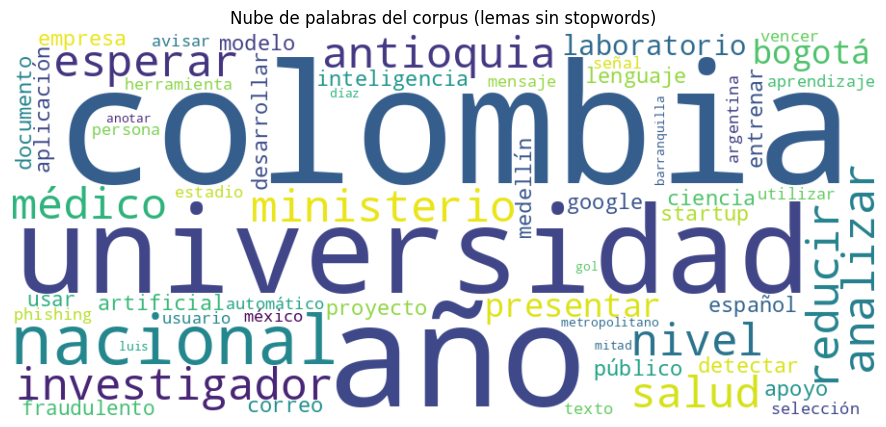

In [28]:
from wordcloud import WordCloud

# Unimos todos los lemas del corpus en un solo texto
texto_total = " ".join(" ".join(lemas) for lemas in df["lemas"])

nube = WordCloud(width=900, height=400, background_color="white",
                 colormap="viridis", max_words=60).generate(texto_total)

plt.figure(figsize=(12, 5))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras del corpus (lemas sin stopwords)")
plt.show()

In [ ]:
# Bigramas (pares de palabras consecutivas) más frecuentes usando CountVectorizer
# ngram_range=(2, 2) → solo bigramas; (1, 2) sería palabras sueltas Y bigramas
vec_bigramas = CountVectorizer(ngram_range=(2, 2))
X_bi = vec_bigramas.fit_transform(df["lemas"].apply(" ".join))

frecuencias = X_bi.sum(axis=0).A1                     # suma por columna → frecuencia total de cada bigrama
bigramas = vec_bigramas.get_feature_names_out()

top_bigramas = sorted(zip(bigramas, frecuencias), key=lambda x: -x[1])[:12]
pd.DataFrame(top_bigramas, columns=["bigrama", "frecuencia"])

,bigrama,frecuencia
0,afectar próximo,1
1,aficionado esperar,1
2,alcanzar nivel,1
3,alto década,1
4,analista esperar,1
5,analizar documento,1
6,analizar texto,1
7,anotar luis,1
8,antioquia encontrar,1
9,antioquia huila,1


In [29]:
# Agrupamiento (clustering) con K-Means sobre los vectores TF-IDF de los lemas
from sklearn.cluster import KMeans

tfidf_lemas = TfidfVectorizer()
X_lemas = tfidf_lemas.fit_transform(df["lemas"].apply(" ".join))

# Pedimos 4 grupos (sabemos que hay 4 temas, pero el algoritmo NO ve las etiquetas)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["grupo"] = kmeans.fit_predict(X_lemas)

# Comparamos el grupo descubierto contra el tema real
print(df[["id", "tema", "grupo"]].sort_values("grupo").to_string(index=False))

# Palabras que definen cada grupo
print("\nPalabras más representativas por grupo:")
terminos = tfidf_lemas.get_feature_names_out()
for g in range(4):
    centro = kmeans.cluster_centers_[g]
    top = [terminos[i] for i in centro.argsort()[-5:][::-1]]
    print(f"  grupo {g}: {top}")

 id       tema  grupo
  1 tecnologia      0
  7      salud      0
  5   economia      1
  4    deporte      1
  8      salud      1
  2 tecnologia      2
  3    deporte      2
  6   economia      3

Palabras más representativas por grupo:
  grupo 0: ['salud', 'nacional', 'ministerio', 'proyecto', 'público']
  grupo 1: ['año', 'reducir', 'esperar', 'revista', 'seguir']
  grupo 2: ['colombia', 'selección', 'vencer', 'metropolitano', 'néstor']
  grupo 3: ['york', 'sequía', 'temer', 'exportación', 'huila']


Si el agrupamiento coincide con los temas reales, el algoritmo "descubrió" la estructura del corpus solo a partir de las palabras. **Con solo 8 documentos es muy probable que no coincida**: cada documento comparte muy pocas palabras con los demás y el algoritmo se guía por coincidencias casuales (*año*, *seguir*). Con cientos o miles de documentos, esta técnica es la base del **modelado de temas** (*topic modeling*). En la sección 12 veremos que los *embeddings* capturan mucho mejor el significado que el conteo de palabras.

> **Ejercicio 11:** cambia `n_clusters` a 2 y a 3. ¿Qué temas se juntan? ¿Tiene sentido?

---
# Parte 2: Modelos preentrenados de Hugging Face

Hasta aquí usamos técnicas **clásicas** basadas en reglas y conteos. Desde 2018, el PLN está dominado por los **transformers**: redes neuronales entrenadas con millones de textos que "entienden" el contexto de cada palabra.

[Hugging Face](https://huggingface.co/models) es un repositorio público con miles de modelos ya entrenados que podemos usar gratis con la librería `transformers`. La función clave es `pipeline("tarea", model="nombre")`: descarga el modelo y lo deja listo para usar en una línea.

Para cada tarea elegimos modelos **que entienden español** y **suficientemente pequeños** para correr en el Colab gratuito.

> **Nota:** Cada modelo se descarga la primera vez (100 MB – 1 GB). Si una celda tarda más de 5 minutos, revisa que tengas GPU activada.

In [30]:
from transformers import pipeline
import torch

# Detectamos si hay GPU disponible (device=0 → primera GPU) o solo CPU
device = 0 if torch.cuda.is_available() else "cpu"
print("Usando GPU" if device == 0 else "Usando CPU (funciona, pero más lento)")

Usando CPU (funciona, pero más lento)


## 12. Sentence Similarity (similitud entre oraciones)

### ¿Qué es?
Un modelo de **embeddings** convierte una oración completa en un **vector de números** (por ejemplo, de 384 dimensiones) de modo que oraciones con **significado parecido** queden **cerca** en ese espacio, **aunque no compartan palabras**.

La cercanía se mide con la **similitud del coseno**: 1 = idénticas, 0 = sin relación.

### ¿Para qué sirve?
Buscadores semánticos ("encuentra documentos que hablen de esto aunque usen otras palabras"), detección de duplicados, sistemas de recomendación, agrupar preguntas frecuentes.

Usaremos `paraphrase-multilingual-MiniLM-L12-v2`, un modelo multilingüe (50+ idiomas, incluido español) de solo ~120 MB.

In [31]:
from sentence_transformers import SentenceTransformer, util

modelo_sim = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

frases = [
    "El equipo colombiano ganó el partido de fútbol.",
    "La selección venció a su rival en el estadio.",
    "El banco central bajó las tasas de interés.",
    "Las vacunas contra la gripe ya están disponibles.",
]

embeddings = modelo_sim.encode(frases)   # una fila de números por frase
print("Forma de los embeddings (frases, dimensiones):", embeddings.shape)

# Matriz de similitud entre todas las frases
similitud = util.cos_sim(embeddings, embeddings)
pd.DataFrame(similitud.numpy(), index=[f[:35] for f in frases], columns=[f"f{i+1}" for i in range(len(frases))]).round(2)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Forma de los embeddings (frases, dimensiones): (4, 384)


,f1,f2,f3,f4
El equipo colombiano ganó el partid,1.00,0.52,-0.03,0.06
La selección venció a su rival en e,0.52,1.00,0.11,-0.05
El banco central bajó las tasas de,-0.03,0.11,1.00,-0.12
Las vacunas contra la gripe ya está,0.06,-0.05,-0.12,1.00


Fíjate: las frases 1 y 2 **no comparten casi ninguna palabra** (*ganó/venció, partido/estadio*) y aun así el modelo las considera muy parecidas. Eso es imposible con TF-IDF, que solo cuenta palabras.

In [32]:
# Buscador semántico sobre nuestro corpus
emb_corpus = modelo_sim.encode(df["texto"].tolist())

def buscar(consulta, k=3):
    emb_q = modelo_sim.encode(consulta)
    puntajes = util.cos_sim(emb_q, emb_corpus)[0]
    mejores = puntajes.argsort(descending=True)[:k]
    print(f"Consulta: '{consulta}'\n")
    for idx in mejores:
        i = int(idx)
        print(f"  [{puntajes[i]:.2f}] doc{df.loc[i, 'id']} ({df.loc[i, 'tema']}): {df.loc[i, 'texto'][:90]}...")

buscar("¿Qué pasó con los precios y la economía?")
print()
buscar("resultados de competencias deportivas")

Consulta: '¿Qué pasó con los precios y la economía?'

  [0.32] doc6 (economia): El precio del café colombiano alcanzó su nivel más alto en una década en la bolsa de Nueva...
  [0.19] doc5 (economia): El Banco de la República decidió reducir la tasa de interés en 25 puntos básicos. La decis...
  [0.04] doc8 (salud): Un estudio de la Universidad de Antioquia encontró que caminar 30 minutos diarios reduce e...

Consulta: 'resultados de competencias deportivas'

  [0.39] doc3 (deporte): La Selección Colombia venció 2-1 a Argentina en el estadio Metropolitano de Barranquilla. ...
  [0.31] doc4 (deporte): El ciclista Egan Bernal ganó la etapa de montaña de la Vuelta a Colombia tras un ataque en...
  [0.11] doc8 (salud): Un estudio de la Universidad de Antioquia encontró que caminar 30 minutos diarios reduce e...


> **Ejercicio 12:** haz una consulta en **inglés** (por ejemplo `"vaccination campaign"`). ¿Encuentra el documento correcto aunque el corpus esté en español? ¿Por qué crees que funciona?

## 13. Text Classification (clasificación de texto)

### ¿Qué es?
Asignar una **categoría** a un texto: tema (deporte/economía), sentimiento (positivo/negativo), spam/no spam, urgente/no urgente...

Veremos **tres enfoques**, de menor a mayor sofisticación:

1. **Clásico supervisado**: TF-IDF + un clasificador de scikit-learn, entrenado con nuestros 8 documentos etiquetados.
2. **Análisis de sentimiento** con un modelo BERT ya entrenado para español.
3. **Zero-shot**: un modelo que clasifica en categorías que **le inventamos en el momento**, sin entrenar nada.

In [33]:
# --- Enfoque 1: clasificador clásico (TF-IDF + Regresión logística) ---
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Entrenamos con el corpus completo (en un proyecto real separaríamos entrenamiento y prueba)
clf = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
clf.fit(df["lemas"].apply(" ".join), df["tema"])

# Probamos con textos NUEVOS que el modelo nunca vio
nuevos = [
    "El delantero marcó dos goles en la final del campeonato.",
    "La inflación subió y el dólar alcanzó un nuevo récord.",
    "Los hospitales reportan aumento de casos de dengue.",
    "Lanzan un chatbot que responde preguntas usando inteligencia artificial.",
]
for texto in nuevos:
    pred = clf.predict([" ".join(lematizar(texto))])[0]
    print(f"{pred:12} ← {texto}")

deporte      ← El delantero marcó dos goles en la final del campeonato.
economia     ← La inflación subió y el dólar alcanzó un nuevo récord.
economia     ← Los hospitales reportan aumento de casos de dengue.
tecnologia   ← Lanzan un chatbot que responde preguntas usando inteligencia artificial.


In [34]:
# --- Enfoque 2: análisis de sentimiento con BERT en español ---
sentimiento = pipeline("sentiment-analysis", model="finiteautomata/beto-sentiment-analysis", device=device)

opiniones = [
    "El taller estuvo excelente, aprendí muchísimo.",
    "La aplicación se cierra sola y perdí todo mi trabajo.",
    "El evento es el próximo martes a las 3 de la tarde.",
    "No me gustó nada la atención, muy lenta.",
]
for texto, r in zip(opiniones, sentimiento(opiniones)):
    print(f"{r['label']:4} ({r['score']:.2f}) ← {texto}")

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/528 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/481k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

POS  (1.00) ← El taller estuvo excelente, aprendí muchísimo.
NEG  (1.00) ← La aplicación se cierra sola y perdí todo mi trabajo.
NEU  (1.00) ← El evento es el próximo martes a las 3 de la tarde.
NEG  (1.00) ← No me gustó nada la atención, muy lenta.


In [35]:
# --- Enfoque 3: clasificación zero-shot (sin entrenamiento) ---
zero_shot = pipeline("zero-shot-classification",
                     model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli", device=device)

categorias = ["deporte", "economía", "salud", "tecnología", "política"]

texto = "El congreso aprobó una reforma para aumentar el presupuesto de los hospitales públicos."
resultado = zero_shot(texto, candidate_labels=categorias, hypothesis_template="Este texto trata sobre {}.")

print(texto, "\n")
for etiqueta, puntaje in zip(resultado["labels"], resultado["scores"]):
    print(f"  {etiqueta:12} {puntaje:.2f} {'█' * int(puntaje * 40)}")

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  558MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 16.3MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

El congreso aprobó una reforma para aumentar el presupuesto de los hospitales públicos. 

  salud        0.56 ██████████████████████
  política     0.24 █████████
  economía     0.20 ███████
  tecnología   0.00 
  deporte      0.00 


> **Ejercicio 13:** inventa tus propias categorías para el clasificador zero-shot (por ejemplo `["queja", "felicitación", "pregunta"]`) y clasifica tres mensajes de clientes. ¿En qué casos se equivoca?

## 14. Question Answering (preguntas y respuestas)

### ¿Qué es?
El **QA extractivo** recibe un **contexto** (un párrafo) y una **pregunta**, y devuelve el **fragmento exacto** del contexto que responde la pregunta. No inventa: subraya la respuesta en el texto.

### ¿Para qué sirve?
Asistentes que responden sobre manuales, contratos o políticas internas; extracción de datos de formularios y documentos.

Usaremos `roberta-base-bne-squad-2.0-es`, un modelo RoBERTa en español ajustado con SQuAD 2.0.

In [36]:
import torch
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

model_name = "jamarju/roberta-base-bne-squad-2.0-es"
tok = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name).to(device)
model.eval()

def responder(pregunta, contexto, max_len=384):
    inputs = tok(pregunta, contexto, return_tensors="pt",
                 truncation="only_second", max_length=max_len,
                 return_offsets_mapping=True)
    offsets = inputs.pop("offset_mapping")[0]
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = model(**inputs)

    start_probs = out.start_logits[0].softmax(-1)
    end_probs = out.end_logits[0].softmax(-1)

    # solo tokens del contexto
    seq_ids = tok(pregunta, contexto, truncation="only_second",
                  max_length=max_len).sequence_ids()
    mask = torch.tensor([s == 1 for s in seq_ids], device=start_probs.device)
    start_probs = start_probs * mask
    end_probs = end_probs * mask

    # mejor par (inicio, fin) con fin >= inicio y span <= 30 tokens
    scores = start_probs[:, None] * end_probs[None, :]
    scores = torch.triu(scores) * ~torch.triu(torch.ones_like(scores), diagonal=30).bool()
    idx = scores.argmax()
    s, e = divmod(idx.item(), scores.shape[1])

    ini, fin = offsets[s][0].item(), offsets[e][1].item()
    return contexto[ini:fin], scores[s, e].item()

contexto = corpus[2]["texto"]
print("CONTEXTO:", contexto, "\n")

preguntas = [
    "¿Quién anotó los goles?",
    "¿Dónde se jugó el partido?",
    "¿Cuál fue el marcador?",
    "¿Quién dirige al equipo?",
]
for p in preguntas:
    ans, score = responder(p, contexto)
    print(f"{p:32} → {ans}  (confianza {score:.2f})")

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/851k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/509k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.46M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CONTEXTO: La Selección Colombia venció 2-1 a Argentina en el estadio Metropolitano de Barranquilla. Los goles fueron anotados por Luis Díaz en la segunda mitad del partido. El equipo dirigido por Néstor Lorenzo sigue invicto en las eliminatorias. 



model.safetensors: reconstructing file:   0%|          |  0.00B /  496MB            

model.safetensors: downloading bytes:           |  0.00B            

¿Quién anotó los goles?          → Luis Díaz  (confianza 1.00)
¿Dónde se jugó el partido?       → Metropolitano de Barranquilla  (confianza 0.41)
¿Cuál fue el marcador?           → Los goles fueron anotados por Luis Díaz  (confianza 0.22)
¿Quién dirige al equipo?         → Néstor Lorenzo  (confianza 1.00)


In [37]:
# QA sobre TODO el corpus: buscamos el documento más relevante (sección 12) y luego preguntamos
def responder_corpus(pregunta):
    emb_q = modelo_sim.encode(pregunta)
    idx = int(util.cos_sim(emb_q, emb_corpus)[0].argmax())    # documento más parecido a la pregunta
    ans, score = responder(pregunta, df.loc[idx, "texto"])    # función QA de la celda anterior
    print(f"{pregunta}\n  → {ans}  (doc{df.loc[idx, 'id']}, confianza {score:.2f})\n")

responder_corpus("¿Cuántos minutos hay que caminar al día?")
responder_corpus("¿Qué decidió el Banco de la República?")
responder_corpus("¿De dónde es Egan Bernal?")

¿Cuántos minutos hay que caminar al día?
  → 30 minutos  (doc8, confianza 0.99)

¿Qué decidió el Banco de la República?
  → reducir la tasa de interés en 25 puntos básicos  (doc5, confianza 0.97)

¿De dónde es Egan Bernal?
  → Zipaquirá  (doc4, confianza 1.00)



> **Ejercicio 14:** haz una pregunta cuya respuesta **no esté** en el corpus. ¿Qué devuelve el modelo y con qué confianza? ¿Cómo usarías el puntaje de confianza en un sistema real?

## 15. Summarization (resumen automático)

### ¿Qué es?
Generar una versión **corta** de un texto conservando lo esencial. Hay dos familias:

* **Extractivo**: selecciona las oraciones más importantes del original (como subrayar).
* **Abstractivo**: **redacta** un texto nuevo, como lo haría una persona. Es lo que hacen los modelos neuronales.

Usaremos un modelo BERT2BERT ajustado con noticias en español. Aprovecharemos para mirar **qué hay detrás de un `pipeline`**: un tokenizador y un modelo.

In [39]:
# Esta vez, en lugar de "pipeline", cargamos las dos piezas que hay detrás de todo pipeline:
#   1. el TOKENIZADOR: convierte texto → números (ids de tokens) y viceversa
#   2. el MODELO: recibe ids y genera nuevos ids
from transformers import AutoTokenizer, EncoderDecoderModel

nombre = "mrm8488/bert2bert_shared-spanish-finetuned-summarization"
tok_resumen = AutoTokenizer.from_pretrained(nombre)
modelo_resumen = EncoderDecoderModel.from_pretrained(nombre)
if device == 0:
    modelo_resumen = modelo_resumen.to("cuda")

def resumir(texto, max_length=60):
    # texto → ids (truncamos a 512 tokens, el máximo que acepta BERT)
    entradas = tok_resumen(texto, return_tensors="pt", truncation=True, max_length=512)
    entradas = {k: v.to(modelo_resumen.device) for k, v in entradas.items()}
    # el modelo genera los ids del resumen
    salida = modelo_resumen.generate(**entradas, max_length=max_length, num_beams=4, early_stopping=True)
    # ids → texto
    return tok_resumen.decode(salida[0], skip_special_tokens=True)

texto_largo = (
    "El Ministerio de Ciencia anunció una convocatoria de 50 mil millones de pesos para financiar proyectos de "
    "inteligencia artificial aplicada a la salud, la agricultura y la educación. Podrán participar universidades, "
    "centros de investigación y empresas de todo el país, en alianzas de mínimo dos instituciones. Los proyectos "
    "deberán presentar resultados en un plazo máximo de dos años y garantizar que los datos utilizados cumplan con "
    "la ley de protección de datos personales. La ministra explicó que la convocatoria busca cerrar la brecha "
    "tecnológica entre las regiones y Bogotá, por lo que el 40 por ciento de los recursos se destinará a "
    "proyectos liderados desde departamentos distintos a Cundinamarca. Las inscripciones estarán abiertas hasta "
    "el 30 de noviembre y los resultados se publicarán en febrero del próximo año."
)

print("ORIGINAL:", len(texto_largo.split()), "palabras")
print("RESUMEN :", resumir(texto_largo))

Loading weights:   0%|          | 0/324 [00:00<?, ?it/s]

[transformers] This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie decoder.bert.embeddings.word_embeddings.weight to decoder.cls.predictions.decoder.weight, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
[transformers] EncoderDecoderModel LOAD REPORT from: mrm8488/bert2bert_shared-spanish-finetuned-summarization
Key                                                                   | Status  | 
----------------------------------------------------------------------+---------+-
decoder.bert.encoder.layer.{0...11}.attention.output.LayerNorm.bias   | MISSING | 
decoder.bert.encoder.layer.{0...11}.intermediate.dense.weight         | MISSING | 
decoder.bert.encoder.layer.{0...11}.attention.self.key.bias           | MISSING | 
decoder.bert.encoder.layer.{0...11}.attention.self.value.weight       | MISSING | 
decoder.bert.encoder.layer.{0...11}.attention.self.query.weight       | MISSING | 
decoder.b

ORIGINAL: 128 palabras
RESUMEN : your yourlll your your your recuerdan recuerdan recuerdanll Googlell inútillleto your your huella your your gastos recuerdan your your plataformaslltuvo recuerdan your Google objetivos nombrell Alice your your Google Google objetivos objetivos objetivosetoeto yourl your religiónll recuerdan yourl


In [40]:
# Resumen extractivo "casero" con lo que ya sabemos: puntuar cada oración por TF-IDF y elegir las 2 mejores
def resumen_extractivo(texto, n=2):
    oraciones = sent_tokenize(texto, language="spanish")
    vec = TfidfVectorizer().fit(oraciones)
    puntajes = vec.transform(oraciones).sum(axis=1).A1     # suma de pesos TF-IDF de cada oración
    mejores = sorted(np.argsort(puntajes)[-n:])            # índices de las n mejores, en orden original
    return " ".join(oraciones[i] for i in mejores)

print(resumen_extractivo(texto_largo))

Los proyectos deberán presentar resultados en un plazo máximo de dos años y garantizar que los datos utilizados cumplan con la ley de protección de datos personales. La ministra explicó que la convocatoria busca cerrar la brecha tecnológica entre las regiones y Bogotá, por lo que el 40 por ciento de los recursos se destinará a proyectos liderados desde departamentos distintos a Cundinamarca.


> **Ejercicio 15:** compara los dos resúmenes. ¿Cuál es más fiel al original? ¿Cuál se lee mejor? ¿Alguno "inventó" información que no estaba en el texto? (A eso se le llama **alucinación**).

## 16. Translation (traducción automática)

### ¿Qué es?
Traducir texto entre idiomas con modelos **secuencia a secuencia** (*seq2seq*): leen la oración completa en el idioma origen y generan la traducción palabra por palabra en el destino.

Usaremos los modelos **Opus-MT** de la Universidad de Helsinki: hay uno por cada par de idiomas, pesan ~300 MB y funcionan sorprendentemente bien.

In [41]:
# En transformers v5 ya no existe pipeline("translation"): cargamos tokenizador + modelo Marian directamente
from transformers import AutoTokenizer, MarianMTModel

def cargar_traductor(nombre):
    tk = AutoTokenizer.from_pretrained(nombre)
    md = MarianMTModel.from_pretrained(nombre).to(device)
    md.eval()
    def traducir(texto):
        entradas = tk(texto, return_tensors="pt", truncation=True, max_length=512).to(md.device)
        with torch.no_grad():
            salida = md.generate(**entradas, num_beams=4, max_new_tokens=256)
        # mismo formato que devolvía el pipeline: [{"translation_text": ...}]
        return [{"translation_text": tk.decode(salida[0], skip_special_tokens=True)}]
    return traducir

traductor_es_en = cargar_traductor("Helsinki-NLP/opus-mt-es-en")
traductor_en_es = cargar_traductor("Helsinki-NLP/opus-mt-en-es")

frases_es = [
    "La Selección Colombia venció 2-1 a Argentina en Barranquilla.",
    "El precio del café alcanzó su nivel más alto en una década.",
    "Los médicos recomiendan vacunarse antes de la temporada de lluvias.",
]
for f in frases_es:
    print("ES:", f)
    print("EN:", traductor_es_en(f)[0]["translation_text"], "\n")

config.json:   0%|          | 0.00/1.44k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.59M [00:00<?, ?B/s]

...

ES: La Selección Colombia venció 2-1 a Argentina en Barranquilla.


[transformers] Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


EN: Colombia won 2-1 to Argentina in Barranquilla. 

ES: El precio del café alcanzó su nivel más alto en una década.


[transformers] Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


EN: The price of coffee reached its highest level in a decade. 

ES: Los médicos recomiendan vacunarse antes de la temporada de lluvias.
EN: Doctors recommend vaccination before the rainy season. 



In [42]:
# Traducción de ida y vuelta: una forma sencilla de evaluar la calidad
original = "El corredor de Zipaquirá recuperó su mejor nivel después de dos años de lesiones."
ingles = traductor_es_en(original)[0]["translation_text"]
vuelta = traductor_en_es(ingles)[0]["translation_text"]

print("Original :", original)
print("→ Inglés :", ingles)
print("→ Español:", vuelta)

[transformers] Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Original : El corredor de Zipaquirá recuperó su mejor nivel después de dos años de lesiones.
→ Inglés : The Zipaquirá corridor regained its best level after two years of injuries.
→ Español: El corredor Zipaquirá recuperó su mejor nivel después de dos años de lesiones.


> **Ejercicio 16:** traduce una frase con **modismos colombianos** ("qué chimba de partido", "estoy mamado"). ¿Qué pasa? ¿Por qué los modelos fallan con el lenguaje coloquial?

## 17. Text Generation (generación de texto)

### ¿Qué es?
Un **modelo de lenguaje** aprende a predecir **la siguiente palabra** dado un texto previo. Si le damos un inicio (*prompt*) y le pedimos que prediga una palabra tras otra, **genera texto nuevo**.

Empezaremos con **GPT-2 en español**, un modelo pequeño (2019) que muestra el mecanismo básico. Verás que el texto es gramatical pero a menudo **sin sentido**: no fue entrenado para seguir instrucciones, solo para continuar texto.

Parámetros importantes:

* `max_new_tokens`: cuántas palabras nuevas generar.
* `temperature`: creatividad. Baja (0.3) = predecible y repetitivo; alta (1.2) = sorprendente y caótico.
* `do_sample=True`: elegir palabras al azar (ponderado por probabilidad) en lugar de siempre la más probable.

In [43]:
generador = pipeline("text-generation", model="datificate/gpt2-small-spanish", device=device)

prompt = "La inteligencia artificial en Colombia"

for temp in [0.3, 0.9]:
    salida = generador(prompt, max_new_tokens=40, do_sample=True, temperature=temp,
                       top_p=0.95, pad_token_id=generador.tokenizer.eos_token_id)
    print(f"--- temperature={temp} ---")
    print(salida[0]["generated_text"], "\n")

config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  510MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: datificate/gpt2-small-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json:   0%|          | 0.00/850k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/508k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'top_p', 'max_new_tokens', 'do_sample', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[tran

--- temperature=0.3 ---
La inteligencia artificial en Colombia ha sido criticada por los gobiernos de Colombia y Ecuador.

El gobierno colombiano ha criticado la política de la Unión Europea de la Unión Europea de la Unión Europea de la Unión Europea de la Unión Europea 

--- temperature=0.9 ---
La inteligencia artificial en Colombia y de Argentina ha sido posible gracias a la utilización de técnicas en las células humanas.

Desde el primer milenio antes de nuestra era, los seres humanos se han adaptado a las máquinas en varias fases 



## 18. Generación de texto usando un LLM

### ¿Qué es?
Un **LLM** (*Large Language Model*, gran modelo de lenguaje) es el mismo principio de GPT-2 pero **miles de veces más grande** y, sobre todo, con una etapa adicional de entrenamiento para **seguir instrucciones** y **conversar** (*instruction tuning*). Por eso ChatGPT, Gemini o Claude responden a lo que se les pide en lugar de solo "continuar el texto".

Usaremos **Qwen2.5-0.5B-Instruct**, un LLM abierto y pequeño (500 millones de parámetros, ~1 GB) que habla español y corre en el Colab gratuito. No es tan capaz como los modelos comerciales, pero muestra exactamente cómo funcionan.

### Formato de chat
Los LLM reciben una **lista de mensajes** con roles:

* `system`: instrucciones generales (quién es el asistente, cómo debe responder).
* `user`: lo que pide la persona.
* `assistant`: lo que responde el modelo.

In [44]:
llm = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct", device=device)

def preguntar_llm(instruccion, sistema="Eres un asistente útil que responde en español de forma breve y clara.",
                  max_new_tokens=150, temperature=0.7):
    mensajes = [
        {"role": "system", "content": sistema},
        {"role": "user", "content": instruccion},
    ]
    salida = llm(mensajes, max_new_tokens=max_new_tokens, do_sample=True, temperature=temperature)
    # La respuesta es el último mensaje de la conversación generada
    return salida[0]["generated_text"][-1]["content"]

print(preguntar_llm("Explica en dos frases qué es el procesamiento de lenguaje natural."))

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


El proceso de procesamiento del lenguaje natural se refiere a la transformación de la información leída por una inteligencia artificial (como una máquina o una computadora) en un idioma que pueda ser comprendido por la inteligencia humana.


In [ ]:
# El mismo LLM puede hacer varias de las tareas anteriores solo con cambiar la instrucción (prompt)

print("RESUMEN:")
print(preguntar_llm(f"Resume en una sola oración esta noticia:\n\n{corpus[4]['texto']}"), "\n")

print("CLASIFICACIÓN:")
print(preguntar_llm(f"¿Este texto es sobre deporte, economía, salud o tecnología? Responde solo con la categoría.\n\n{corpus[7]['texto']}"), "\n")

print("EXTRACCIÓN DE ENTIDADES:")
print(preguntar_llm(f"Lista las personas, lugares y organizaciones mencionadas en este texto:\n\n{corpus[2]['texto']}"), "\n")

print("GENERACIÓN CREATIVA:")
print(preguntar_llm("Escribe un titular de noticia, en tono positivo, sobre un avance en energías renovables en Colombia.", temperature=1.0))

### Reflexión: ¿modelos especializados o un LLM para todo?

| | Modelos especializados (secciones 12–16) | LLM (sección 18) |
|---|---|---|
| Tamaño | 100 MB – 500 MB | 1 GB – cientos de GB |
| Velocidad | Muy rápidos | Lentos y costosos |
| Precisión en su tarea | Alta y **predecible** | Buena, pero puede **alucinar** |
| Flexibilidad | Una sola tarea | Cualquier tarea que se describa en texto |
| Salida | Estructurada (etiqueta, puntaje, fragmento) | Texto libre que hay que interpretar |

> **Ejercicio 18:** pídele al LLM que responda una pregunta cuya respuesta no está en el texto que le das (por ejemplo, la edad de Luis Díaz a partir de la noticia del partido). ¿Inventa la respuesta? Compara con lo que hizo el modelo de QA extractivo en la sección 14.

---
## 19. Cierre y entrega

### Lo que recorrimos

| # | Técnica | Librería | ¿Qué hace? |
|---|---|---|---|
| 2 | Normalización | `re`, `nltk` | Limpia y unifica el texto |
| 3 | Stopwords | `nltk` | Elimina palabras sin contenido |
| 4 | Stemming | `nltk` | Recorta palabras a su raíz |
| 5 | Term Frequency | `sklearn` | Cuenta palabras por documento |
| 6 | IDF / TF-IDF | `sklearn` | Pondera palabras raras e informativas |
| 7 | Lematización | `spacy` | Reduce palabras a su forma de diccionario |
| 8 | POS Tagging | `spacy` | Etiqueta la categoría gramatical |
| 9 | Parsing | `spacy` | Descubre la estructura de la oración |
| 10 | NER | `spacy` | Detecta personas, lugares, organizaciones |
| 11 | Text mining | `wordcloud`, `sklearn` | Nubes de palabras, n-gramas, clustering |
| 12 | Sentence similarity | `sentence-transformers` | Compara significados |
| 13 | Text classification | `sklearn`, `transformers` | Asigna categorías / sentimiento |
| 14 | Question answering | `transformers` | Encuentra respuestas en un texto |
| 15 | Summarization | `transformers` | Resume textos |
| 16 | Translation | `transformers` | Traduce entre idiomas |
| 17 | Text generation | `transformers` | Continúa un texto |
| 18 | LLM | `transformers` | Sigue instrucciones en lenguaje natural |

### Entrega del taller

1. Reemplaza el corpus de la sección 1 por **al menos 8 textos propios** en español (noticias, reseñas, publicaciones, correos, etc.) con **mínimo 3 categorías**.
2. Ejecuta el notebook completo con tu corpus y resuelve los ejercicios marcados en cada sección.
3. Agrega al final una celda de texto con tus **conclusiones** (mínimo 10 líneas): ¿qué técnica funcionó mejor con tus textos?, ¿en cuál encontraste errores?, ¿qué aplicación real le darías?
4. Guarda el notebook con tus resultados (`Archivo → Descargar → .ipynb`) y súbelo a tu repositorio de GitHub. Entrega el enlace.

### Rúbrica

| Criterio | Puntos |
|---|---|
| Corpus propio cargado y procesado por toda la tubería clásica (secciones 2–11) | 30 |
| Tareas con modelos preentrenados ejecutadas sobre el corpus propio (12–18) | 30 |
| Ejercicios resueltos y comentados | 25 |
| Conclusiones argumentadas | 15 |

### Para seguir aprendiendo
* Curso gratuito de Hugging Face: https://huggingface.co/learn/nlp-course
* Documentación de spaCy en español: https://spacy.io/models/es
* Libro (gratuito): *Speech and Language Processing*, Jurafsky & Martin: https://web.stanford.edu/~jurafsky/slp3/